For this code, assuming we already implement DecisionTree, we can just use from sklearn and only implement the bagging mechanism

In [2]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

np.random.seed(42)

class RandomForestClassifier:
    # Initialize the random forest parameters: number of trees, max features, etc.
    def __init__(self, n_estimators, max_features=None, max_depth=None, random_state=None):
        # Store the parameters
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.random_state = random_state
        # Prepare storage for the trees
        self.trees = [
            DecisionTreeClassifier(
                max_features=self.max_features,
                max_depth=self.max_depth,
                random_state=(self.random_state + i) if self.random_state is not None else None,
            )
            for i in range(self.n_estimators)
        ]
        self.rng = np.random.default_rng(random_state)

    # Fit the ensemble on the data using bootstrap sampling for each tree
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # For each estimator:
        for i in range(self.n_estimators):
            # Generate a bootstrap sample from X, y using numpy
            idxs = self.rng.choice(n_samples, size=n_samples, replace=True)
            X_bs = X[idxs].copy()
            y_bs = y[idxs].copy()
            self.trees[i].fit(X_bs,y_bs)

    # Predict class labels for samples in X
    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])  # shape: (n_trees, n_samples)
        vals,counts = np.unique(preds, return_counts=True)
        index = np.argmax(counts)
        return vals[index]        

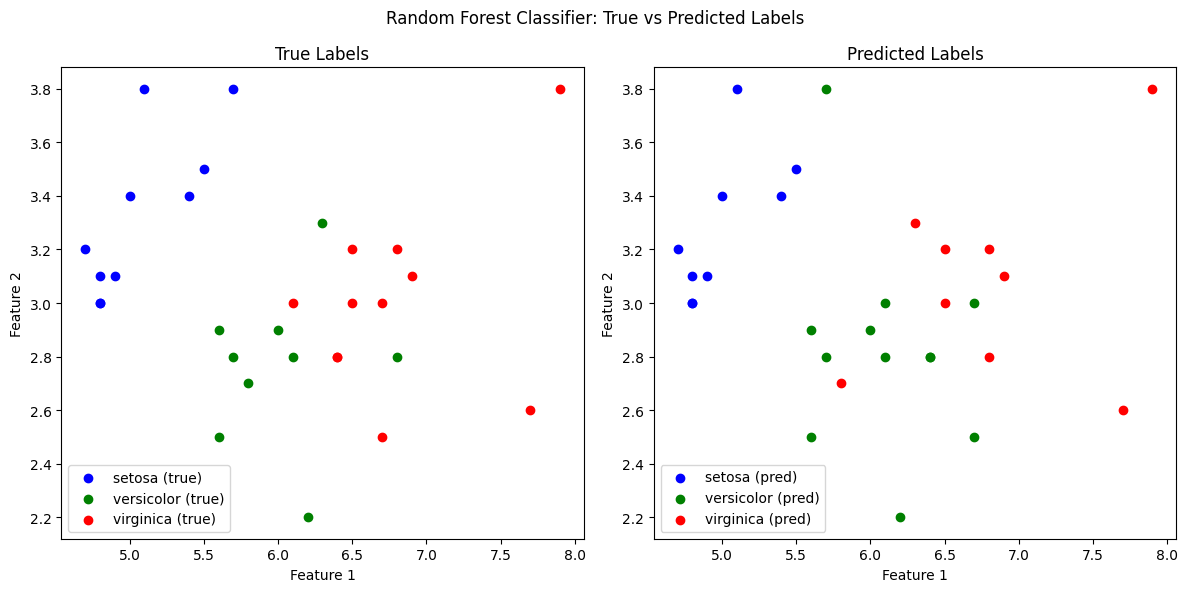

Number predicted as setosa: 9
Number predicted as versicolor: 12
Number predicted as virginica: 9


In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()

# We'll use only the first 2 features for visualization
X = iris.data[:, :2]
y = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a RandomForestClassifier with 5 trees
rf = RandomForestClassifier(n_estimators=5, max_features=1, random_state=42)

# Train the classifier
rf.fit(X_train, y_train)

# Make predictions on the test data (Predict per sample)
y_pred = np.array([rf.predict(X_test[i].reshape(1, -1)) for i in range(len(X_test))])

# Create side-by-side plots: left = truth, right = predicted
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
for i, color in enumerate(['b', 'g', 'r']):
    axs[0].scatter(X_test[y_test==i, 0], X_test[y_test==i, 1], 
                   c=color, label=f"{iris.target_names[i]} (true)")
axs[0].set_title("True Labels")
axs[0].set_xlabel('Feature 1')
axs[0].set_ylabel('Feature 2')
axs[0].legend()

# Plot predictions
for i, color in enumerate(['b', 'g', 'r']):
    axs[1].scatter(X_test[y_pred==i, 0], X_test[y_pred==i, 1], 
                   c=color, label=f"{iris.target_names[i]} (pred)")
axs[1].set_title("Predicted Labels")
axs[1].set_xlabel('Feature 1')
axs[1].set_ylabel('Feature 2')
axs[1].legend()

plt.suptitle('Random Forest Classifier: True vs Predicted Labels')
plt.tight_layout()
plt.show()

# Also count the number of predicted samples for each class
from collections import Counter
pred_counts = Counter(y_pred)
for i, name in enumerate(iris.target_names):
    count = pred_counts.get(i, 0)
    print(f"Number predicted as {name}: {count}")